In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# =====================================================
# Parameters (EDIT THESE)
# =====================================================

r = 0.25
c = 1.0
T_L = 20
beta0 = 1/T_L

b = 0.05
d = 0.01
lam = 0.05
sigma = 0.0005
gamma = 1/T_L

# Trait grid
n_alpha = 1001
alpha_vals = np.linspace(0, 1, n_alpha)

omega = 4*((1/(1-d/b))**(1/T_L)-1)/r
alpha_min = (1-(1-omega*c)**0.5)/(2*c)
alpha_max = (1+(1-omega*c)**0.5)/(2*c)

In [18]:
# =====================================================
# Transmission functions
# =====================================================

def beta_single(alpha):
    """
    beta_i = beta0*(1+r(1-c alpha)alpha)^T_L
    """
    return beta0 * (1 + r * (1 - c * alpha) * alpha) ** T_L


def beta_mr(alpha_r, alpha_m):
    """
    Compute beta_mr from recursion

    x_r(0)=x_m(0)=1

    x_i(t+1)=x_i(t)+r*x_i(t)*(1-c*alpha_i)*alpha_bar

    alpha_bar = (alpha_r*x_r + alpha_m*x_m)/(x_r+x_m)

    beta_mr = beta0*x_m(T_L)
    """

    xr = 1.0
    xm = 1.0

    for _ in range(T_L):

        alpha_bar = (alpha_r * xr + alpha_m * xm) / (xr + xm)
        
        delxr = r * xr * (1 - c * alpha_r) * alpha_bar
        delxm = r * xm * (1 - c * alpha_m) * alpha_bar
        xr += delxr
        xm += delxm

    return beta0 * xm


In [19]:
# =====================================================
# Resident equilibrium
# =====================================================

from scipy.integrate import solve_ivp
import numpy as np

def resident_equilibrium(alpha_r):

    beta_r = beta_single(alpha_r)
    beta_rr = beta_r

    def ode(t, y):

        # Prevent tiny negative values
        S, P, I, Irr = np.maximum(y, 0)

        N = S + P + I + Irr

        force = beta_r * I + 2 * beta_rr * Irr

        dS = b*S*(1-N) - S*force - d*S

        dP = (
            b*P*(1-N)
            + (lam*S - P)*force
            - (sigma + d)*P
        )

        dI = (
            (1-lam)*S*force
            + sigma*P
            - gamma*I
        )

        dIrr = (
            P*force
            - gamma*Irr
        )

        return [dS, dP, dI, dIrr]

    # Initial condition
    y = np.array([0.99, 0.01, 1e-6, 1e-6])

    # Integrate in chunks
    t = 0
    while t < 1000:

        sol = solve_ivp(
            ode,
            [t, t+5],
            y,
            method='RK45',
            rtol=1e-8,
            atol=1e-10,
        )

        # Last solution
        y = sol.y[:, -1]

        # Check convergence
        if np.max(np.abs(sol.y[:, -1] - sol.y[:, -2])) < 1e-10:
            break

        t += 5

    S, P, I, Irr = y

    if S + P < 1e-12:
        return np.nan

    return P/(S+P)



# =====================================================
# Compute resident equilibrium
# =====================================================

pstar = np.zeros(n_alpha)
astar = np.zeros(n_alpha)

for i, alpha_r in enumerate(alpha_vals):
    pstar[i] = resident_equilibrium(alpha_r)
    astar[i] = 1/((2+pstar[i])*c)

In [20]:
# =====================================================
# Pairwise invasibility
# =====================================================

pip = np.zeros((n_alpha, n_alpha))

for i, alpha_r in enumerate(alpha_vals):
    
    if alpha_r < alpha_min or alpha_r > alpha_max:
        
        for j, alpha_m in enumerate(alpha_vals):
            
            if alpha_m < alpha_min or alpha_m > alpha_max:
                
                pip[j, i] = 0.5
                
            else:
                
                pip[j, i] = 1.0
        
    else:

        pr = pstar[i]

        beta_r = beta_single(alpha_r)
        beta_rr = beta_r

        resident_growth = beta_r * (1 - pr) + 2 * beta_rr * pr

        for j, alpha_m in enumerate(alpha_vals):
            
            if alpha_m < alpha_min or alpha_m > alpha_max:
                
                pip[j, i] = 0.0
                
            else:

                beta_m = beta_single(alpha_m)

                betaMR = beta_mr(alpha_r, alpha_m)

                mutant_growth = beta_m * (1 - pr) + 2 * betaMR * pr

                if mutant_growth > resident_growth:
                
                    pip[j, i] = 1
            
                else:
                
                    pip[j, i] = 0


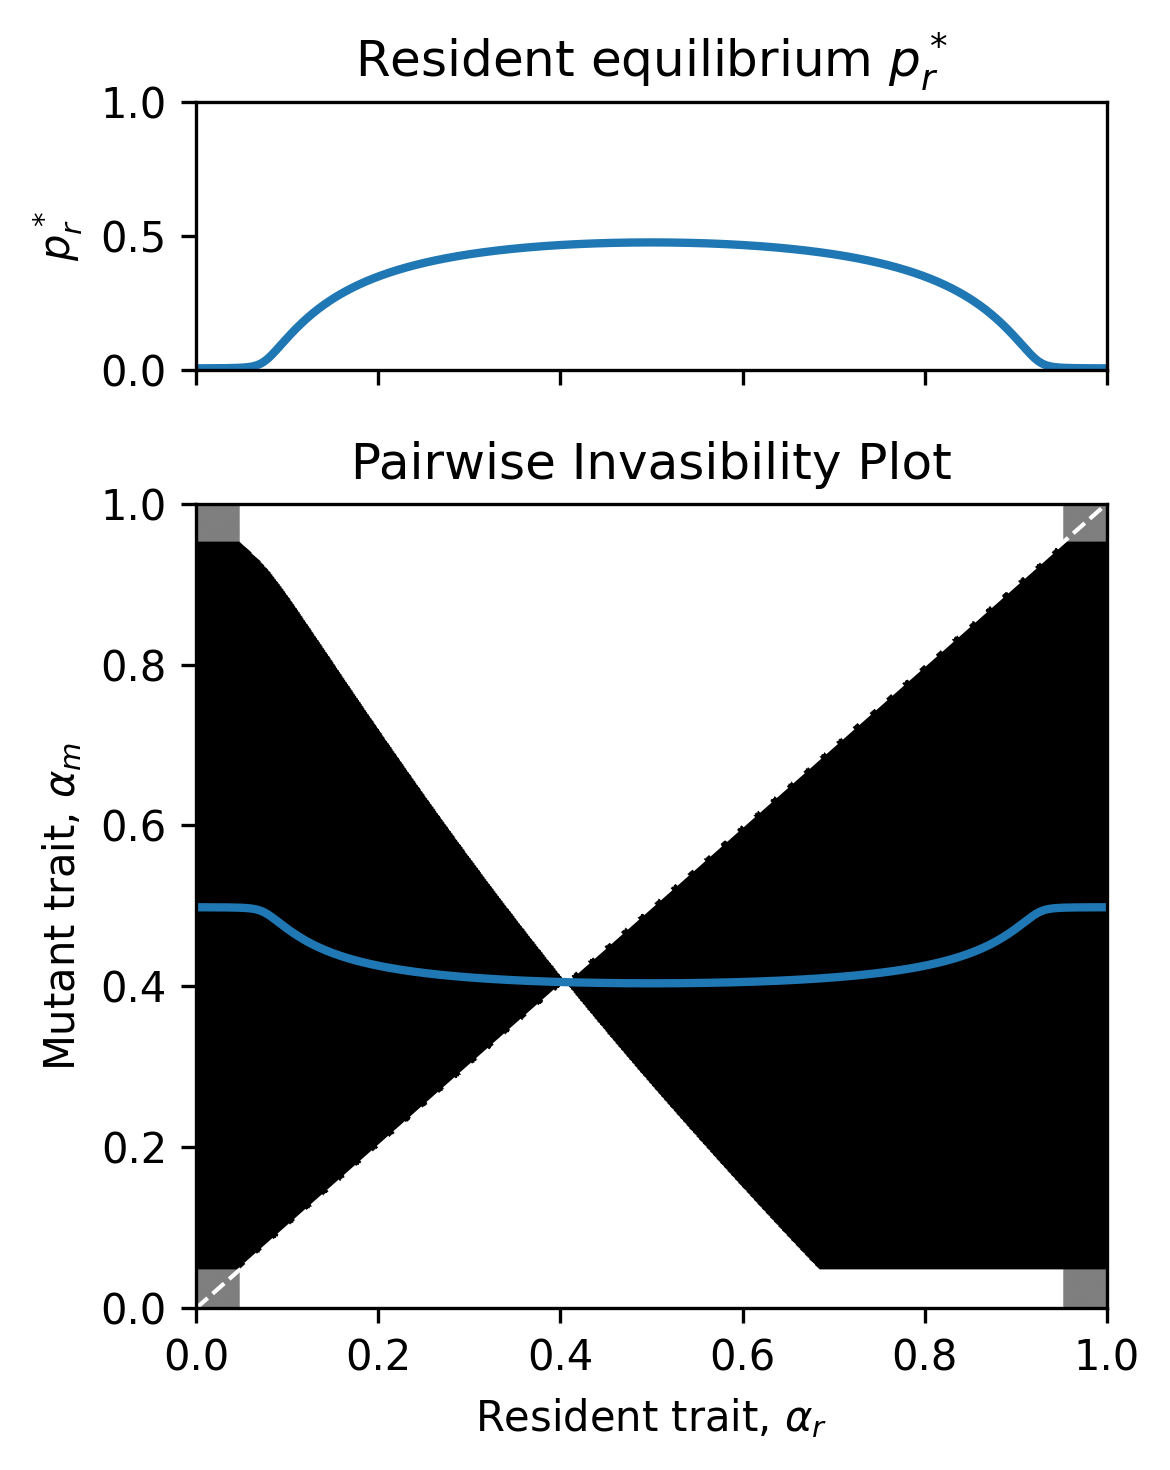

In [21]:
# =====================================================
# Plot
# =====================================================

fig, (ax1, ax2) = plt.subplots(

    2, 1,

    figsize=(4, 5),

    sharex=True,

    gridspec_kw={'height_ratios': [1, 3]},
    
    dpi = 300

)

ax1.plot(alpha_vals, pstar, lw=2)

ax1.set_ylim(0, 1)

# ax1.set_xlabel(r'$\alpha_r$')
ax1.set_ylabel(r'$p_r^*$')
ax1.set_title(r'Resident equilibrium $p_r^*$')

# ---------------------------------------
# Bottom panel
# ---------------------------------------

im = ax2.imshow(
    pip,
    origin='lower',
    extent=[0, 1, 0, 1],
    aspect='auto',
    cmap='gray_r'
)

ax2.plot([0, 1], [0, 1], 'w--', lw=1)

ax2.plot(alpha_vals, astar, lw=2)

ax2.set_xlabel(r'Resident trait, $\alpha_r$')
ax2.set_ylabel(r'Mutant trait, $\alpha_m$')
ax2.set_title('Pairwise Invasibility Plot')

plt.tight_layout()

In [227]:
c = 0.5
xs = np.linspace(0,1,100)
R0 = np.array([(1-d/b)*beta_single(alpha)/gamma for alpha in xs])

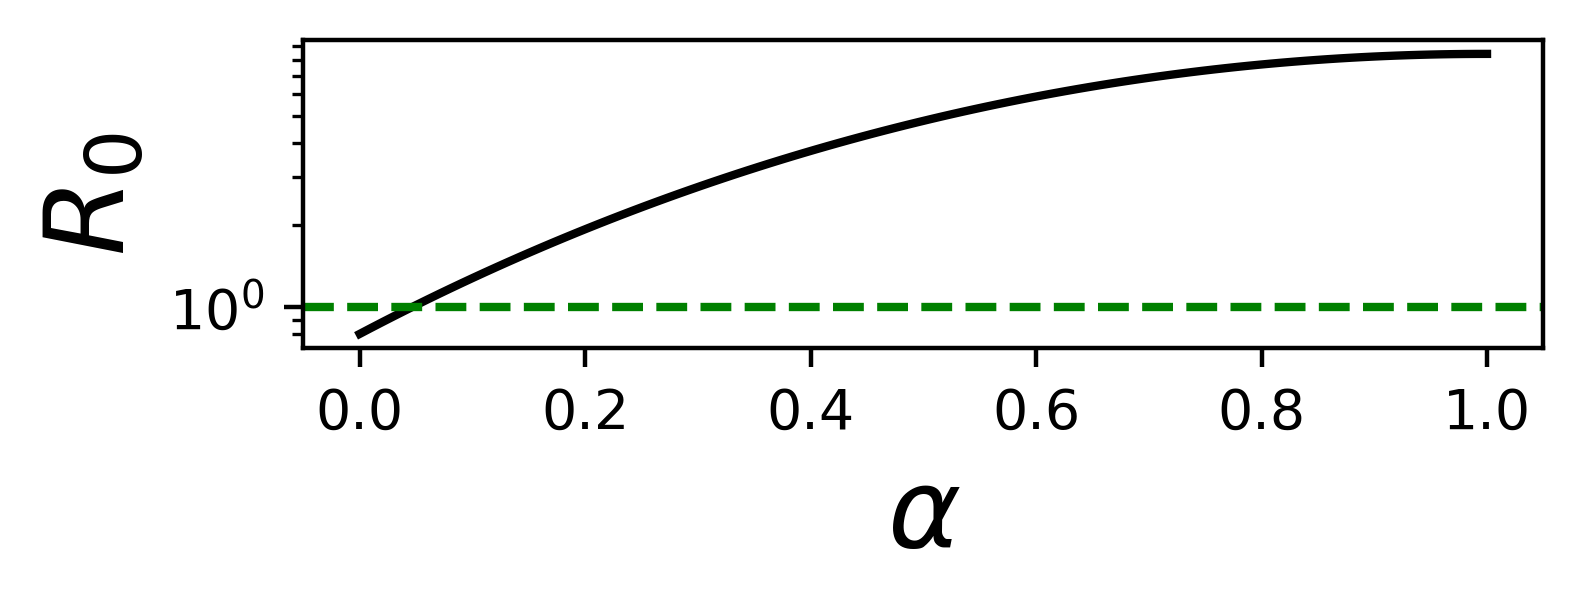

In [251]:
plt.subplots(figsize=(4,1), dpi=400)
plt.plot(xs, R0, 'black')
plt.axhline(1, c='green', linestyle='dashed')
plt.ylabel(r'$R_{0}$', fontsize=20)
plt.xlabel(r'$\alpha$', fontsize=20)
plt.yticks([1])
plt.yscale('log')